In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=sns.load_dataset('titanic')
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [ ]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [ ]:
df['deck'].unique()

[NaN, 'C', 'E', 'G', 'D', 'A', 'B', 'F']
Categories (7, object): ['A', 'B', 'C', 'D', 'E', 'F', 'G']

In [ ]:
df['sibsp'].unique()

array([1, 0, 3, 4, 2, 5, 8])

In [ ]:
df['age']=df['age'].fillna(df['age'].mean()).astype('int32')

In [ ]:
df[['embarked','embark_town']]= df[['embarked','embark_town']].fillna(df[['embarked','embark_town']].mode().iloc[0])


In [ ]:
df=df.drop(columns=['adult_male','deck','who'],axis=1)

In [ ]:
df.head(3)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,embark_town,alive,alone
0,0,3,male,22,1,0,7.2500,S,Third,Southampton,no,False
1,1,1,female,38,1,0,71.2833,C,First,Cherbourg,yes,False
2,1,3,female,26,0,0,7.9250,S,Third,Southampton,yes,True


<Axes: xlabel='fare', ylabel='Count'>

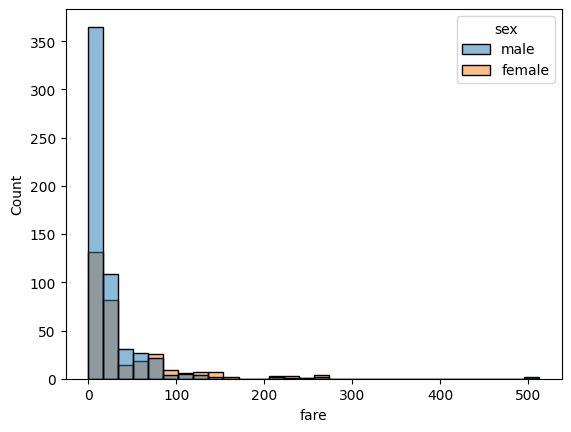

In [ ]:
sns.histplot(data=df,x='fare',hue='sex',bins=30)

<Axes: xlabel='survived', ylabel='fare'>

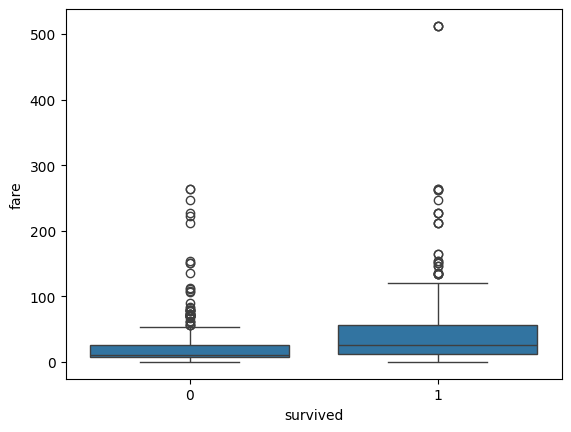

In [ ]:
sns.boxplot(data=df,x='survived',y='fare')

<Axes: xlabel='age', ylabel='sex'>

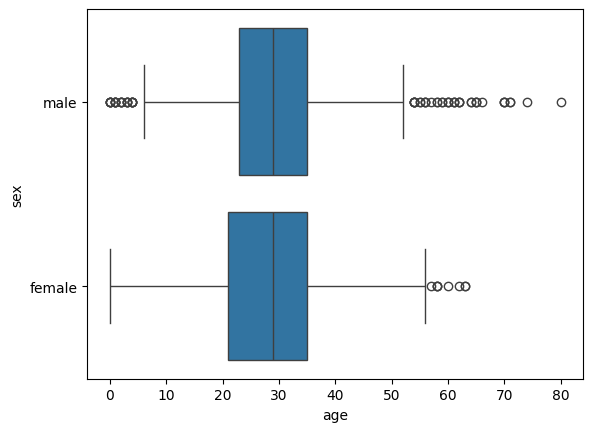

In [ ]:
sns.boxplot(data=df,x='age',y='sex')

<Axes: xlabel='pclass', ylabel='fare'>

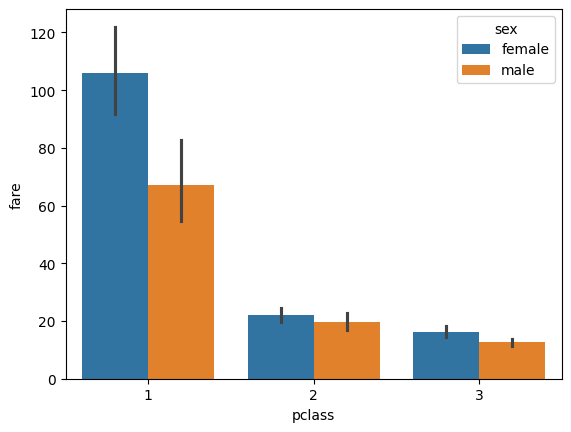

In [ ]:
sns.barplot(data=df,x='pclass',y='fare',hue='sex')

<Axes: xlabel='age', ylabel='fare'>

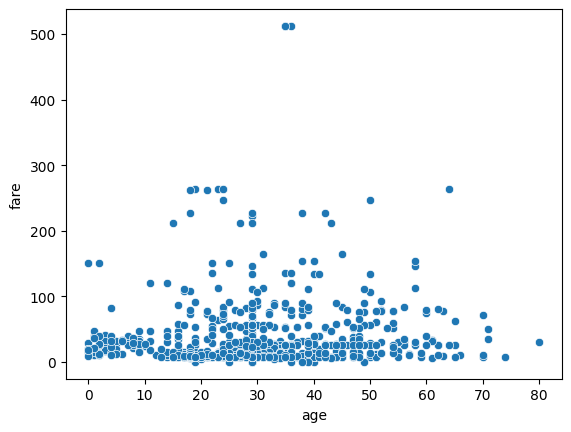

In [ ]:
sns.scatterplot(data=df,x='age',y='fare')

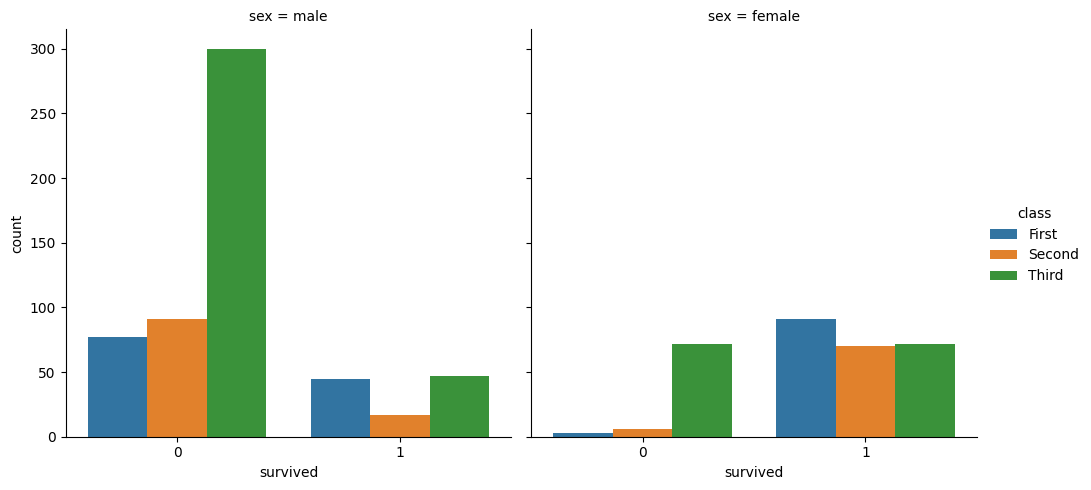

In [ ]:
sns.catplot(data=df,x='survived',hue='class',col='sex',kind='count')

In [ ]:
sex_survived=df.groupby('sex')['survived'].sum()
sex_survived

,survived
sex,
female,233
male,109


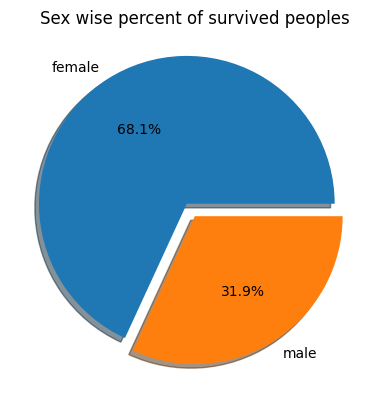

In [ ]:
explode=(0.1,0)
plt.pie(sex_survived,explode=explode,labels=sex_survived.index,autopct='%1.1f%%',shadow=True,)
plt.title('Sex wise percent of survived peoples')
plt.show()

In [ ]:
df.head(3)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,embark_town,alive,alone
0,0,3,male,22,1,0,7.2500,S,Third,Southampton,no,False
1,1,1,female,38,1,0,71.2833,C,First,Cherbourg,yes,False
2,1,3,female,26,0,0,7.9250,S,Third,Southampton,yes,True


In [ ]:
class_survived=df.groupby('class')['survived'].sum()
class_survived

/tmp/ipykernel_427/2179762526.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  class_survived=df.groupby('class')['survived'].sum()


,survived
class,
First,136
Second,87
Third,119


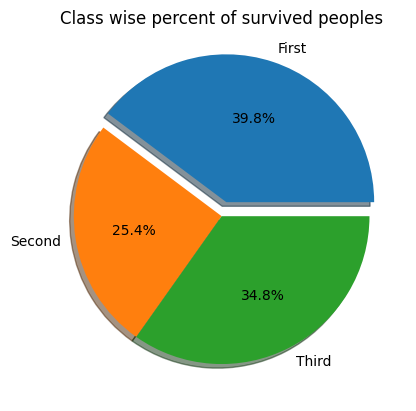

In [ ]:
explode=(0.1,0,0)
plt.pie(class_survived,explode=explode,labels=class_survived.index,autopct='%1.1f%%',shadow=True,)
plt.title('Class wise percent of survived peoples')
plt.show()